# ***Data Visualization***

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [10]:
df = pd.read_csv("data/cleaned_property_data.csv")
df

,type,area_in_marla,bedroom,bath,location_city,price
0,House,20.000000,7.0,6.0,Islamabad,190000000.0
1,House,14.200000,6.0,6.0,Islamabad,60000000.0
2,House,20.000000,8.0,7.0,Islamabad,70000000.0
3,House,8.000000,4.0,6.0,Islamabad,26500000.0
4,Flat,2.400000,1.0,1.0,Islamabad,4000000.0
...,...,...,...,...,...,...
84972,Shop,3.305785,0.0,0.0,Sukkur,5900000.0
84973,Shop,2.571166,0.0,0.0,Sukkur,7500000.0
84974,Shop,1.322314,0.0,0.0,Sukkur,30000000.0
84975,Other,80.000000,0.0,0.0,Wah,55000000.0


---

## Histogram of Price Distribution

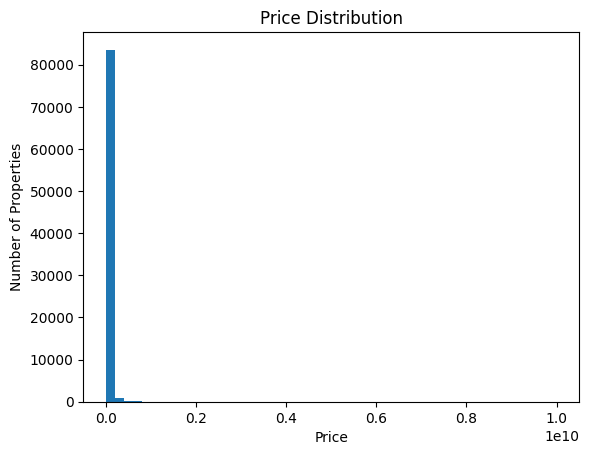

In [31]:
plt.hist(df["price"], bins=50)
plt.xlabel("Price")
plt.ylabel("Number of Properties")
plt.title("Price Distribution")
plt.show()

1e10 = 10 Billion

Most properties are priced below 500 million, but a few extreme properties stretch the scale all the way to 10 billion, making the original distribution almost unreadable. The number of properties are so less that they are almost unseen-able on the graph.

It's not good for our linear model as ML models patterns on error minimization. Say the price of property is 10m, the model predicts it to be 9m. Error is 1m. Now, again if the price is 10B and model predicts it to be 9B, that's a 1B error for the model. The model will shift it's focus from those 80k+ under 500m price tag to the heavily priced properties. To overcome this, we can use log transformation on the price col before feeding it to the model. After prediction we reverse it to get back actual rupee values.

Let's see these two graphs together.

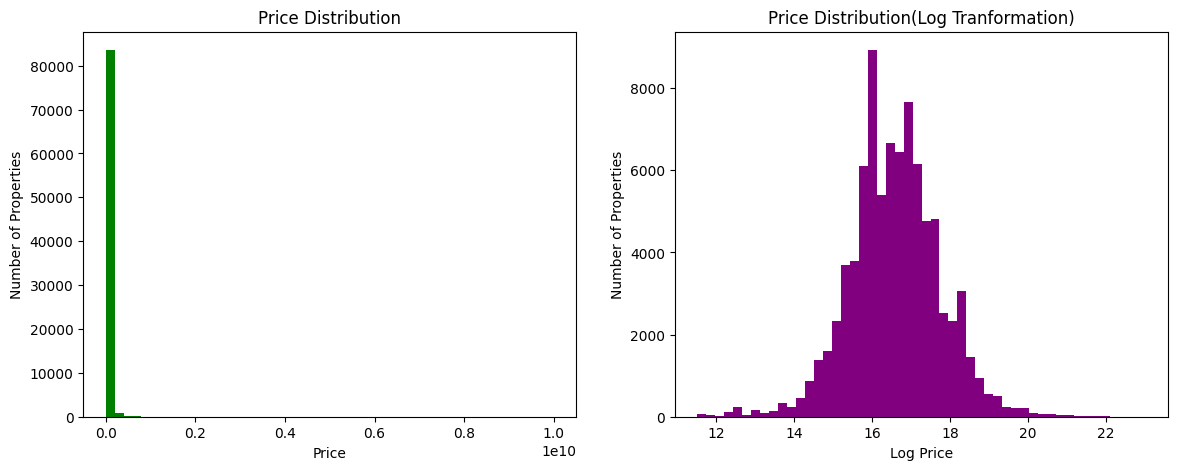

In [39]:
fig, axes = plt.subplots(1, 2, figsize = (14,5))

axes[0].hist(df["price"], bins=50, color = "green")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Number of Properties")
axes[0].set_title("Price Distribution")

axes[1].hist(np.log1p(df["price"]), bins=50, color = "purple")  #log1p means : log(1 + x)
axes[1].set_xlabel("Log Price")
axes[1].set_ylabel("Number of Properties")
axes[1].set_title("Price Distribution(Log Tranformation)")

plt.show()

You can see that the after log transformation, most values of the distribution are centered aroung 15-18.

---

# Property Analysis

Let's check the number of properties per type and average price per property type.

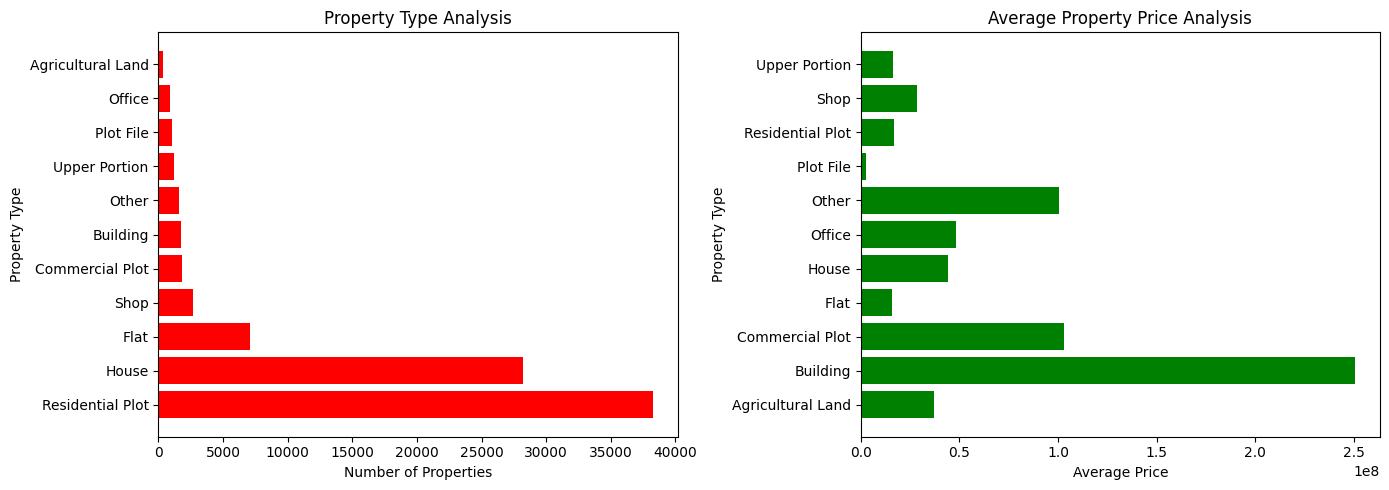

In [64]:
fig, axes = plt.subplots(1, 2,  figsize = (14, 5))

X = df["type"].value_counts().index
y = df["type"].value_counts().values
axes[0].barh(X, y, color = "red")
axes[0].set_xlabel("Number of Properties")
axes[0].set_ylabel("Property Type")
axes[0].set_title("Property Type Analysis")

X =  df.groupby("type")["price"].mean().index
y =  df.groupby("type")["price"].mean().values
axes[1].barh(X, y, color = "green")
axes[1].set_xlabel("Average Price")
axes[1].set_ylabel("Property Type")
axes[1].set_title("Average Property Price Analysis")

plt.tight_layout()
plt.show()

- Residential Plots and Houses are available in large amounts.
- While Agricultural Lands and offices are in very short amount.
- Buildings are the most expensive, followed by Commercial plots. Buildings being expensive makes sense as these are multi-storied.
- Plot Files, Upper Portions and Flats are the cheapest among the available types.

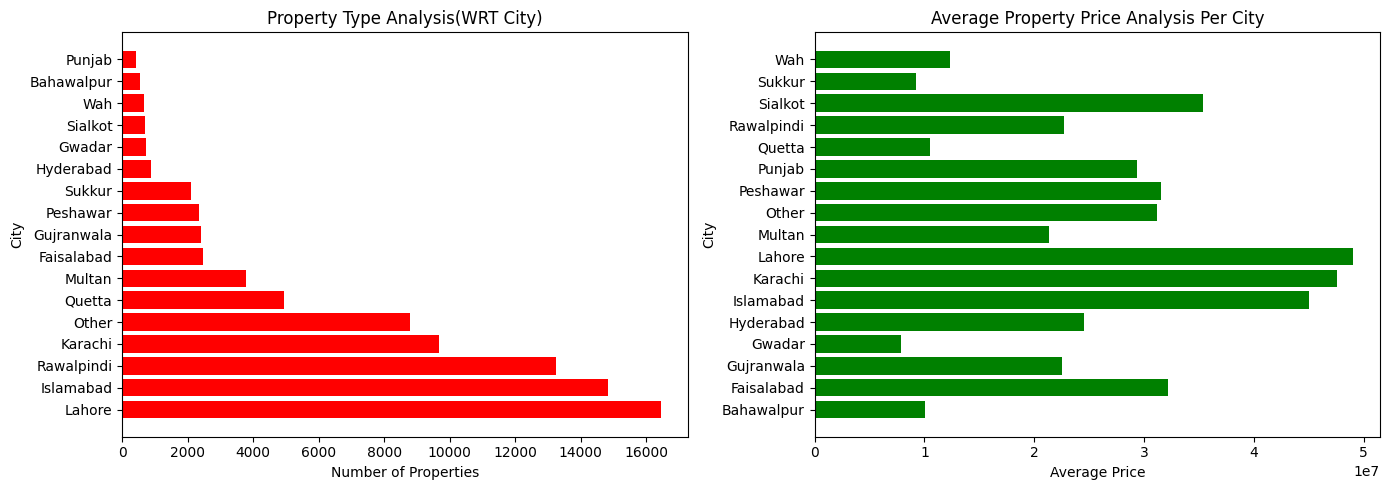

In [69]:
fig, axes = plt.subplots(1, 2,  figsize = (14, 5))

X = df["location_city"].value_counts().index
y = df["location_city"].value_counts().values
axes[0].barh(X, y, color = "red")
axes[0].set_xlabel("Number of Properties")
axes[0].set_ylabel("City")
axes[0].set_title("Property Type Analysis(WRT City)")

X =  df.groupby("location_city")["price"].mean().index
y =  df.groupby("location_city")["price"].mean().values
axes[1].barh(X, y, color = "green")
axes[1].set_xlabel("Average Price")
axes[1].set_ylabel("City")
axes[1].set_title("Average Property Price Analysis Per City")

plt.tight_layout()
plt.show()

First of all, ***Punjab is not a city***. It's a province and Lahore, FSD, etc comes under it. So the lowest property count for Punjab doesn't make sense. Gotta do something about it.

In [70]:
df["location_city"] = df["location_city"].replace("Punjab", "Other")

Let's make the graphs again.

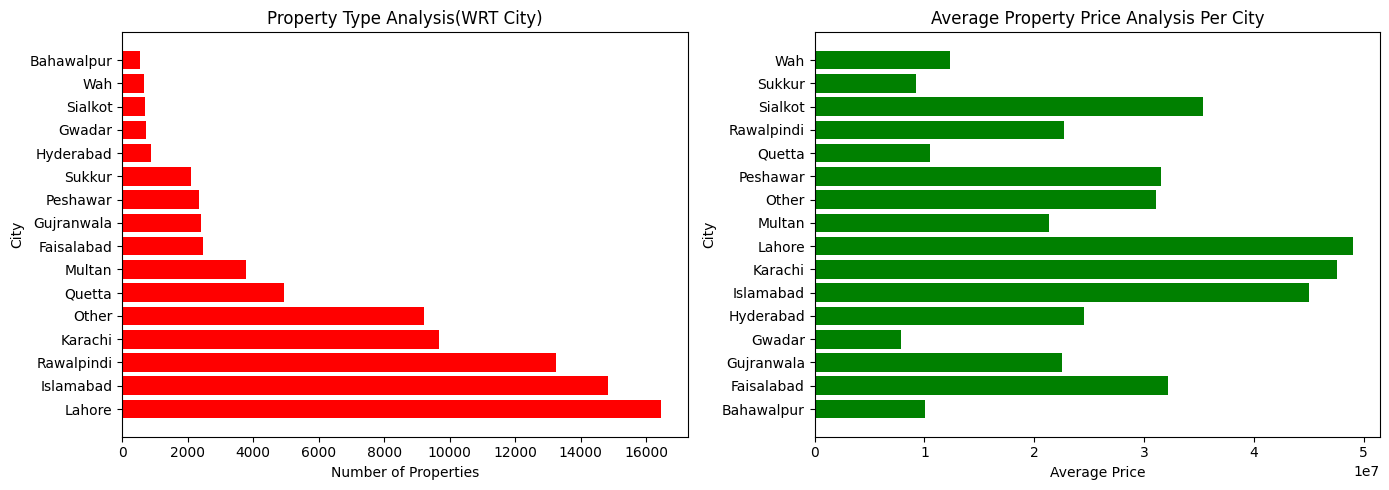

In [71]:
fig, axes = plt.subplots(1, 2,  figsize = (14, 5))

X = df["location_city"].value_counts().index
y = df["location_city"].value_counts().values
axes[0].barh(X, y, color = "red")
axes[0].set_xlabel("Number of Properties")
axes[0].set_ylabel("City")
axes[0].set_title("Property Type Analysis(WRT City)")

X =  df.groupby("location_city")["price"].mean().index
y =  df.groupby("location_city")["price"].mean().values
axes[1].barh(X, y, color = "green")
axes[1].set_xlabel("Average Price")
axes[1].set_ylabel("City")
axes[1].set_title("Average Property Price Analysis Per City")

plt.tight_layout()
plt.show()

Yes, this looks better.

- Lahore has the highest number of properties available for sale, followed by ISB and Rawalpindi.
- Bahawalpur with the lowest, followed by Wah Cantt.
- Properties in Lahore, KHI and ISB are the most expensive ones.
- The cheapest properties are in Gwadar, Quetta and Sukkur.
- There is one more thing worth noticing, Sialkot has pretty high average prices despite having one of the lowest property counts.

---

## Area vs Price

Scatter plot: area_in_marla vs price
Do bigger properties cost more? Is the relationship linear?

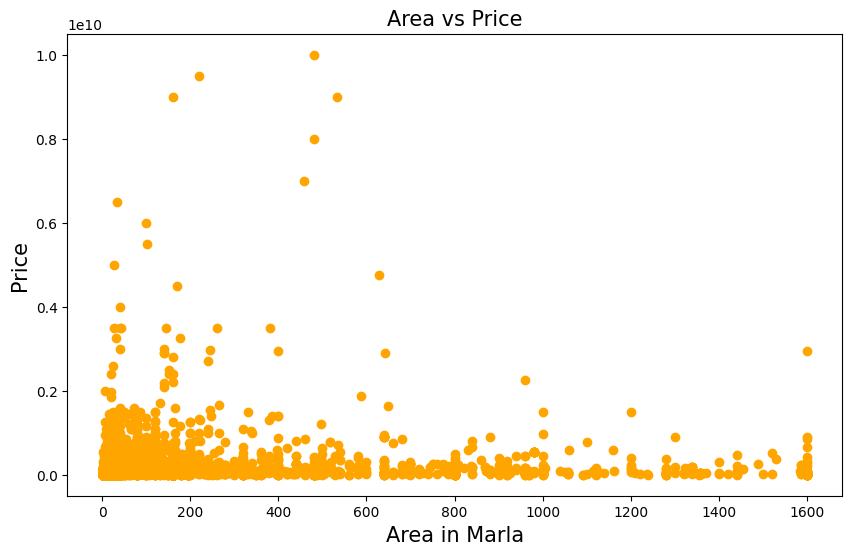

In [89]:
plt.figure(figsize = (10,6))
plt.scatter(df["area_in_marla"], df["price"], color = "orange")
plt.xlabel("Area in Marla", fontsize = 15)
plt.ylabel("Price", fontsize = 15)
plt.title("Area vs Price", fontsize = 15)
plt.show()

There are some properties with small size that are really expensive. That could be because of the location, or the type of the property. And the relationship b/w area and price is not linear, meaning that increase in area doesn't certainly means increase in price.

Let's check it with Log Transformation

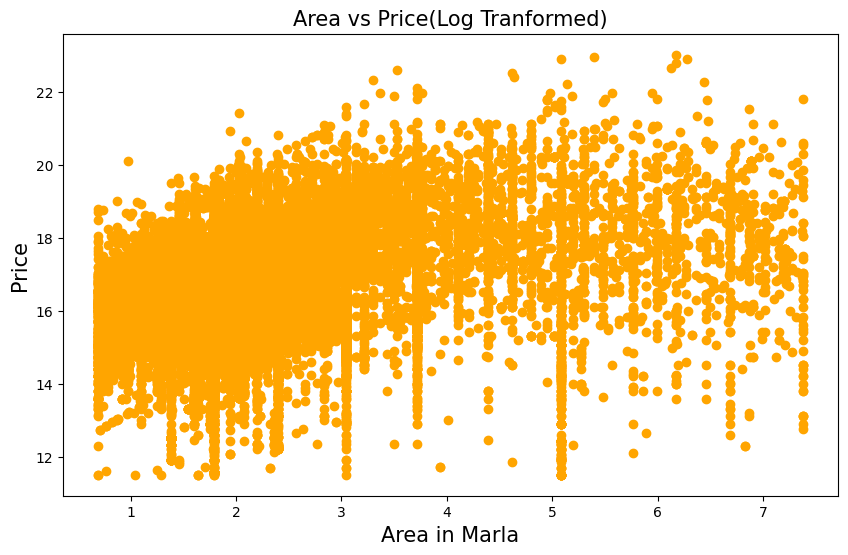

In [92]:
plt.figure(figsize = (10,6))
plt.scatter(np.log1p(df["area_in_marla"]), np.log1p(df["price"]), color = "orange")
plt.xlabel("Area in Marla", fontsize = 15)
plt.ylabel("Price", fontsize = 15)
plt.title("Area vs Price(Log Tranformed)", fontsize = 15)
plt.show()

We can see that large areas have large price, but still there are some smaller properties with large price tag. It means that the price is not dependent of area only, location, and other factors also affect the price.

---

## Bedroom & Bath Analysis

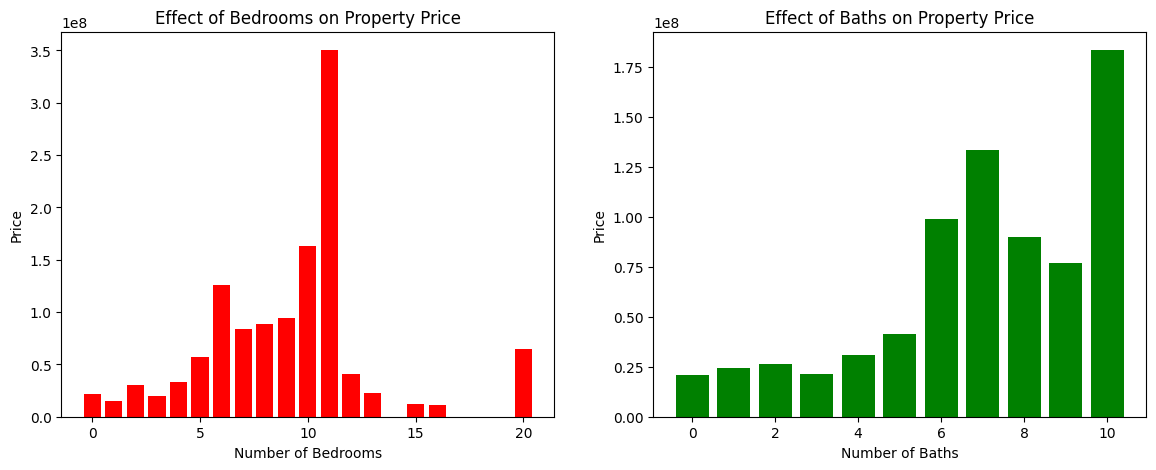

In [106]:
fig, axes = plt.subplots(1, 2,  figsize = (14, 5))

X = df.groupby("bedroom")["price"].mean().index
y = df.groupby("bedroom")["price"].mean().values
axes[0].bar(X, y, color = "red")
axes[0].set_xlabel("Number of Bedrooms")
axes[0].set_ylabel("Price")
axes[0].set_title("Effect of Bedrooms on Property Price")

X = df.groupby("bath")["price"].mean().index
y = df.groupby("bath")["price"].mean().values
axes[1].bar(X, y, color = "green")
axes[1].set_xlabel("Number of Baths")
axes[1].set_ylabel("Price")
axes[1].set_title("Effect of Baths on Property Price")

plt.show()

- Bedrooms doesn't have a linear relationship with price, more bedrooms don't mean higher price.
- The general upward trend makes more sense for bathrooms since bathrooms are a stronger indicator of property quality.

---

## Correlation Heatmap

Correlation measures how strongly two variables move together. The value always ranges from -1 to 1:

- 1.0 = perfect positive relationship. One goes up, other goes up
- -1.0 = perfect negative relationship. One goes up, other goes down
- 0.0 = no relationship at all

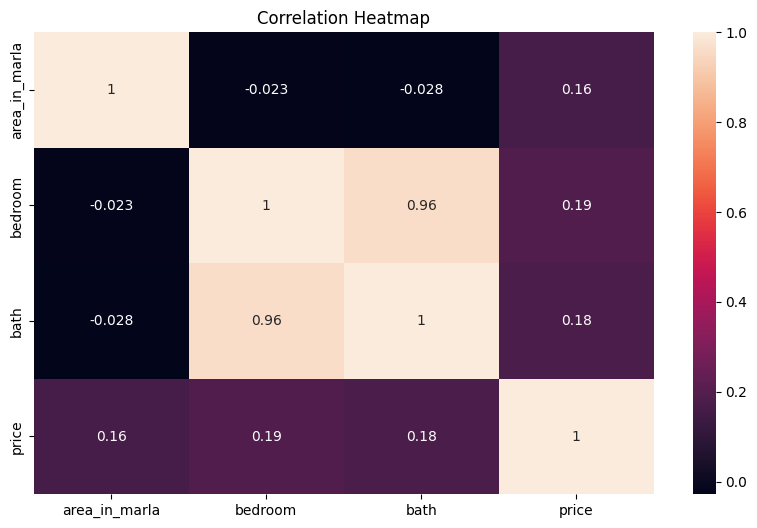

In [111]:
import seaborn as sn

plt.figure(figsize = (10, 6))
sn.heatmap(df[["area_in_marla", "bedroom", "bath", "price"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

- Okay so bedrooms and baths have a strong corr.
- Area and Price have a weak corr, as we earlier.
- Same goes for price with bedroom or bath, weak correlation.

---

## Saving the changes made in the dataset

In [115]:
df.to_csv("data/cleaned_property_data_v2.csv", index = False)